<a href="https://colab.research.google.com/github/wwcbyang/DL/blob/main/perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 퍼셉트론

### 기본개념
* 퍼셉트론(perceptron): 여러 입력 신호로 부터 하나의 신호를 출력하는 '**알고리즘**'
* y = w1x1 + w2x2
    * w1, w2: 가중치
    * x1, x2: 입력(뉴련, 노드)
    * y: 출력
* y = 0 if (w1x1 + w2x2 <= θ) else 1
    * θ: 임계값
* y = 0 if (w1x1 + w2x2 + b <= 0) else 1
    * b: 편향(bias)

### 논리회로 with 퍼셉트론
* AND, NAND, OR 게이트를 퍼셉트론으로 구현

In [ ]:
import numpy as np

In [ ]:
# AND 게이트
def AND(x1, x2):
    x = np.array([x1, x2])
    w = np.array([0.5, 0.5])
    b = -0.7
    tmp = np.sum(x * w) + b
    if tmp <= 0:
        return 0
    else:
        return 1

In [ ]:
# AND 게이트 테스트
print(AND(0, 0)) # 0
print(AND(1, 0)) # expect: 0
print(AND(0, 1)) # expect: 0
print(AND(1, 1)) # expect: 1

0
0
0
1


In [ ]:
# NAND 게이트
def NAND(x1, x2):
    x = np.array([x1, x2])
    w = np.array([-0.5, -0.5])
    b = 0.7
    tmp = np.sum(x * w) + b
    if tmp <= 0:
        return 0
    else:
        return 1

In [ ]:
print(NAND(0, 0)) # expect: 1
print(NAND(1, 0)) # expect: 1
print(NAND(0, 1)) # expect: 1
print(NAND(1, 1)) # expect: 0

1
1
1
0


In [ ]:
# OR 게이트
def OR(x1, x2):
    x = np.array([x1, x2])
    w = np.array([0.5, 0.5])
    b = -0.3
    tmp = np.sum(x * w) + b
    if tmp <= 0:
        return 0
    else:
        return 1

In [ ]:
print(OR(0, 0)) # expect: 0
print(OR(1, 0)) # expect: 1
print(OR(0, 1)) # expect: 1
print(OR(1, 1)) # expect: 1

0
1
1
1


### 퍼셉트론의 한계, XOR(베타적 논리합)
* 직선 하나만으로는 XOR의 논리 분리 영역(0 or 1)을 만드는 것이 불가능하다.
* 직선이라는 제약이 없다면 가능하다.(비선형)
* 퍼셉트론의 한계를 '다층 퍼셉트론', 층을 쌓아서 해결할 수 있다.
* XOR을 AND, OR, NAND로 표현할 수 있다.
    * 층을 쌓아서 '비선형'을 표현할 수 있다! -> 다층 퍼셉트론

In [ ]:
# XOR 구현 with 이미 만든 게이트
def XOR(x1, x2):
    s1 = NAND(x1, x2)
    s2 = OR(x1, x2)
    y = AND(s1, s2)
    return y

In [ ]:
print(XOR(0, 0)) # expect: 0
print(XOR(1, 0)) # expect: 1
print(XOR(0, 1)) # expect: 1
print(XOR(1, 1)) # expect: 0

0
1
1
0


## 신경망

### 퍼셉트론에서 신경망 관점으로
* 퍼셉트론은 아래와 같이 식을 구성했다.
    * y = 0 if (b + w1x1 + w2x2) <= 0
    * y = 1 if (b + w1x1 + w2x2) > 0
    * w1, w2는 가중치로, 각 신호의 '영향력'
    * b는 편향으로, 출력함수의 활성화정도를 제어했다.
* 이제, b 또한 상수 1노드의 가중치로 생각하고, 아래와 같이 생각해보자.
    * y = h(b*1 + w1x1 + w2x2)
    * h(x) = 0 if x <= 0 else 1
* 좀만 더 바꿔보자,
    * a = h(b*1 + w1x1 + w2x2)
    * y = h(a)
        * h(x) = 0 if x <= 0 else 1
        * ---> h(x)가 '입력신호를 출력신호로 변환'하는 역할을 한다.
        * 위와 같은 함수를 '**활성화 함수**'라고 한다.






### 활성화 함수(Activation function)
* 다양한 활성화 함수가 있지만, 3가지 활성화 함수를 먼저 구현
    * 계단 함수(step function)
    * 시그모이드 함수(sigmoid function)
    * ReLU 함수(Rectified Linear Unit)

In [18]:
### 계단함수
def step_function(x):
    y = x > 0
    return y.astype(int)

In [19]:
print(step_function(np.array([1])))
print(step_function(np.array([1, 2])))
print(step_function(np.array([-1, 0, 1])))

[1]
[1 1]
[0 0 1]


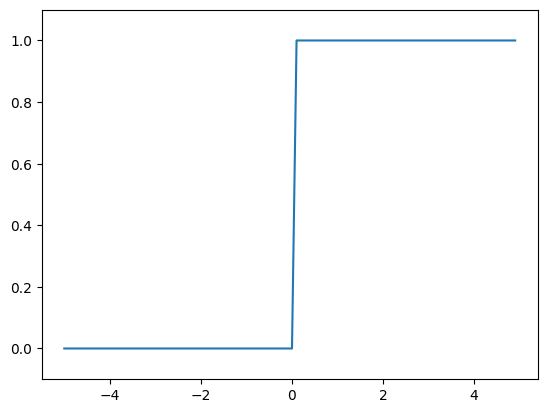

In [28]:
### 계단함수를 함수를 그려보자
import numpy as np
import matplotlib.pyplot as plt

def step_func(x):
    return np.array(x > 0, dtype=int)

x = np.arange(-5.0, 5.0, 0.1) # numpy.ndarray
y = step_func(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()